In [63]:
!pip install yfinance --quiet


In [64]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime
warnings.filterwarnings('ignore')

In [65]:
tickers = ['TCS.NS', 'INFY.NS', 'RELIANCE.NS']

end_date = datetime.date.today()
data = yf.download(tickers, start='2023-01-01', end=end_date, auto_adjust=True)['Close']

print("✅ Live data loaded!")
print(f"Data fetched till: {end_date}")
print(data.tail())

[*********************100%***********************]  3 of 3 completed

✅ Live data loaded!
Data fetched till: 2026-03-20
Ticker          INFY.NS  RELIANCE.NS       TCS.NS
Date                                             
2026-03-13  1248.300049  1380.699951  2410.500000
2026-03-16  1249.800049  1395.099976  2409.199951
2026-03-17  1232.900024  1397.599976  2391.699951
2026-03-18  1267.099976  1408.099976  2440.800049
2026-03-19  1220.800049  1384.800049  2356.000000


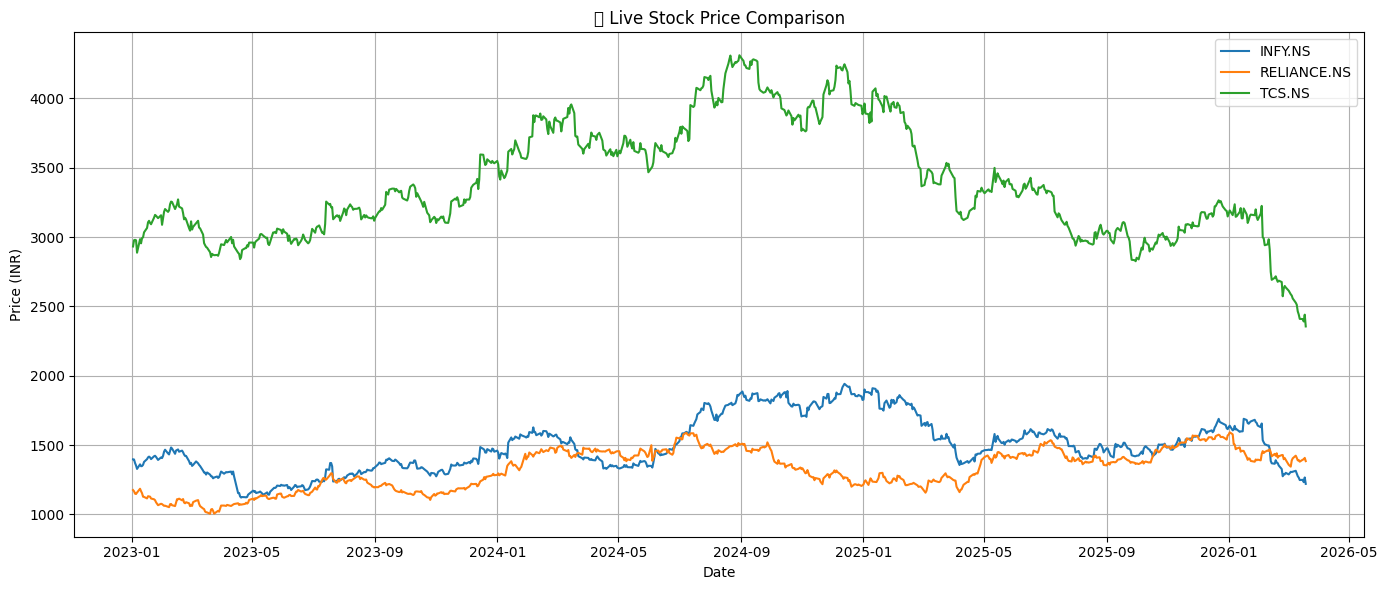

In [66]:
plt.figure(figsize=(14,6))
for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title('📈 Live Stock Price Comparison')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

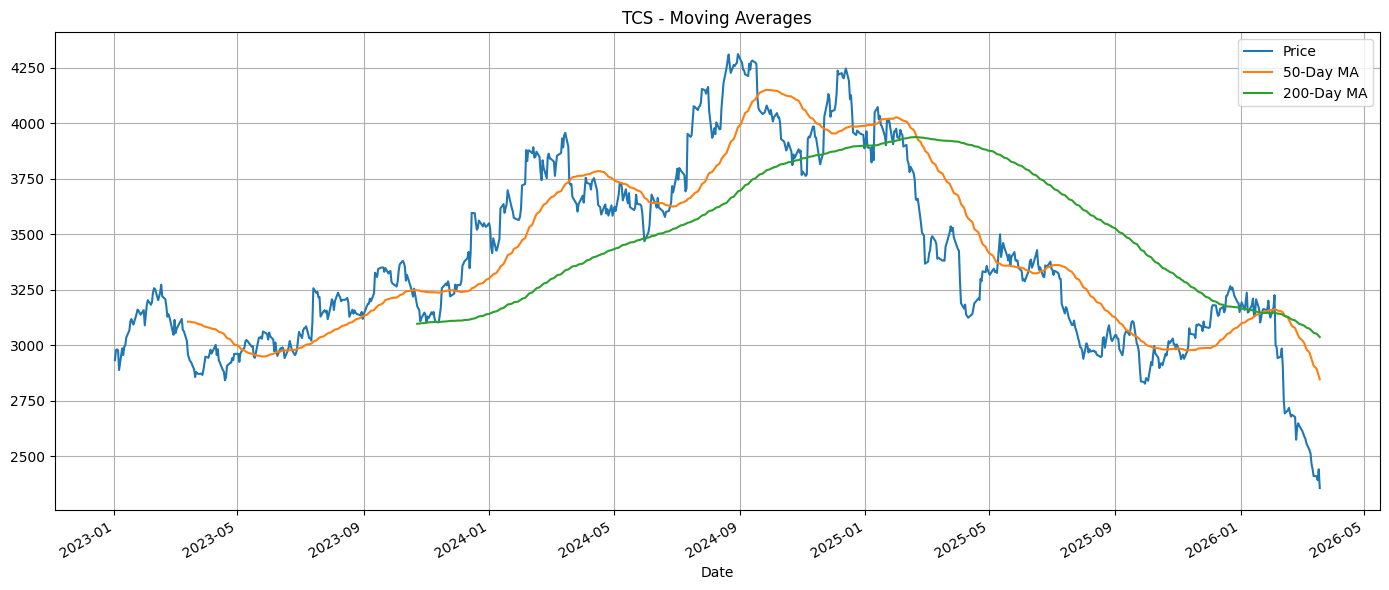

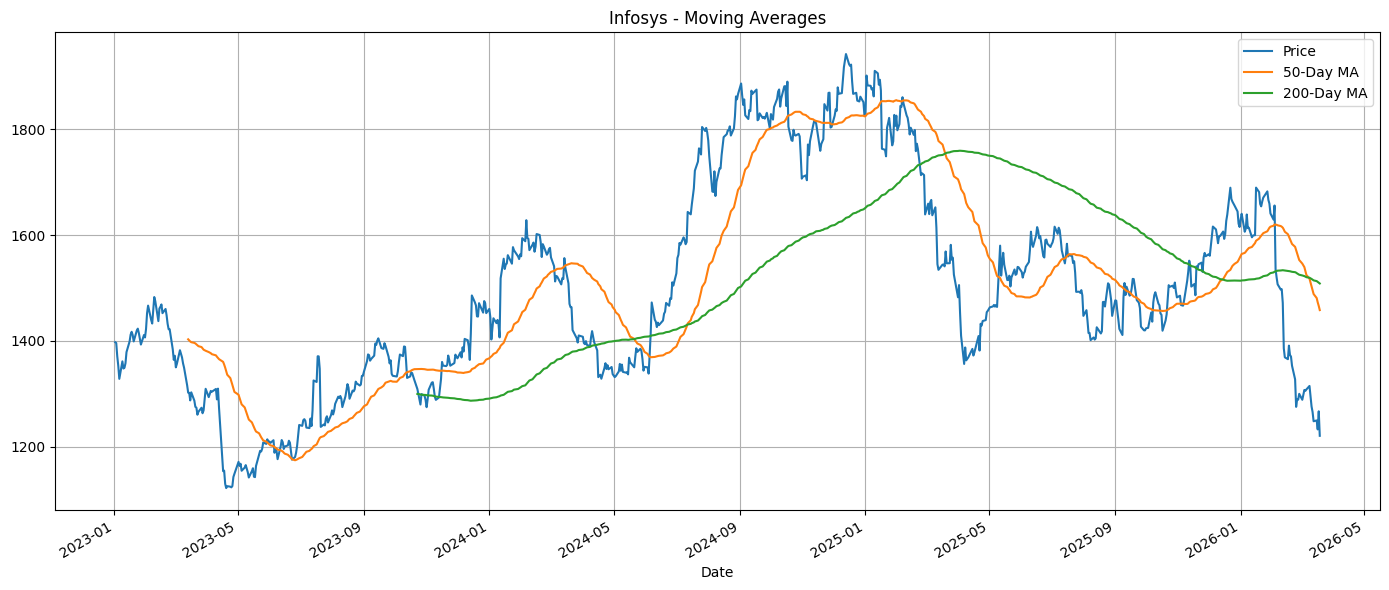

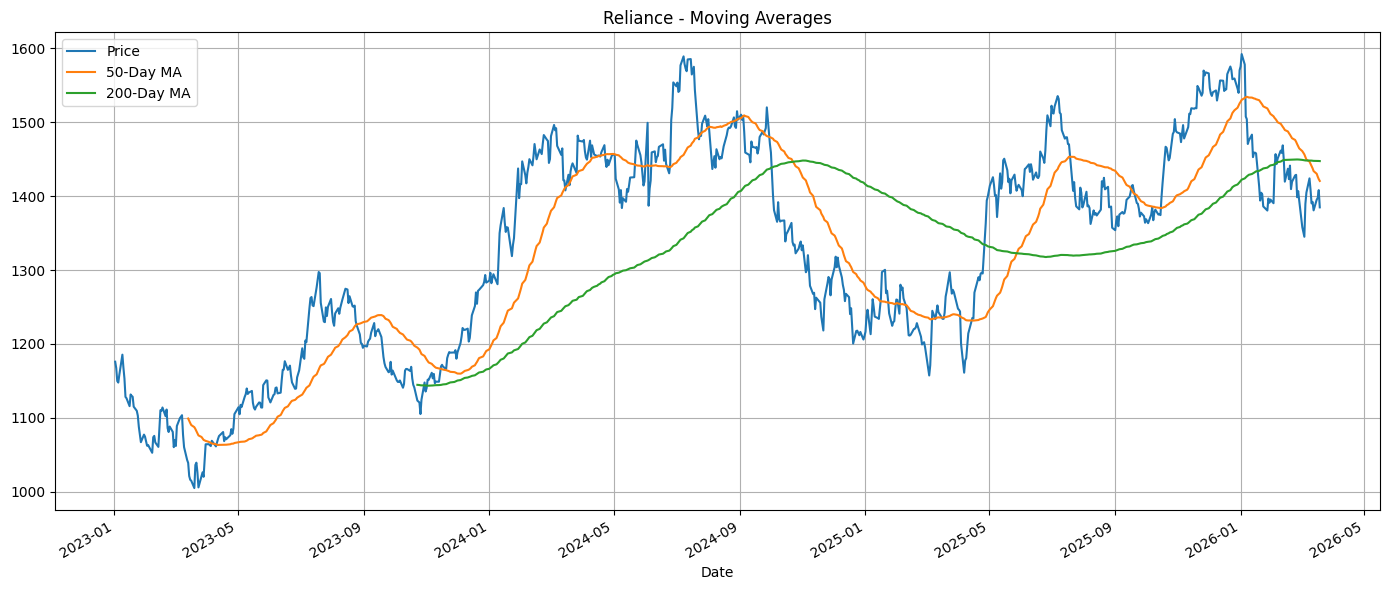

In [67]:
companies = {
    'TCS.NS': 'TCS',
    'INFY.NS': 'Infosys',
    'RELIANCE.NS': 'Reliance'
}

for ticker, name in companies.items():
    stock = data[ticker].dropna()

    ma_df = pd.DataFrame()
    ma_df['Price'] = stock
    ma_df['50-Day MA'] = stock.rolling(50).mean()
    ma_df['200-Day MA'] = stock.rolling(200).mean()

    ma_df.plot(figsize=(14,6), title=f'{name} - Moving Averages')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

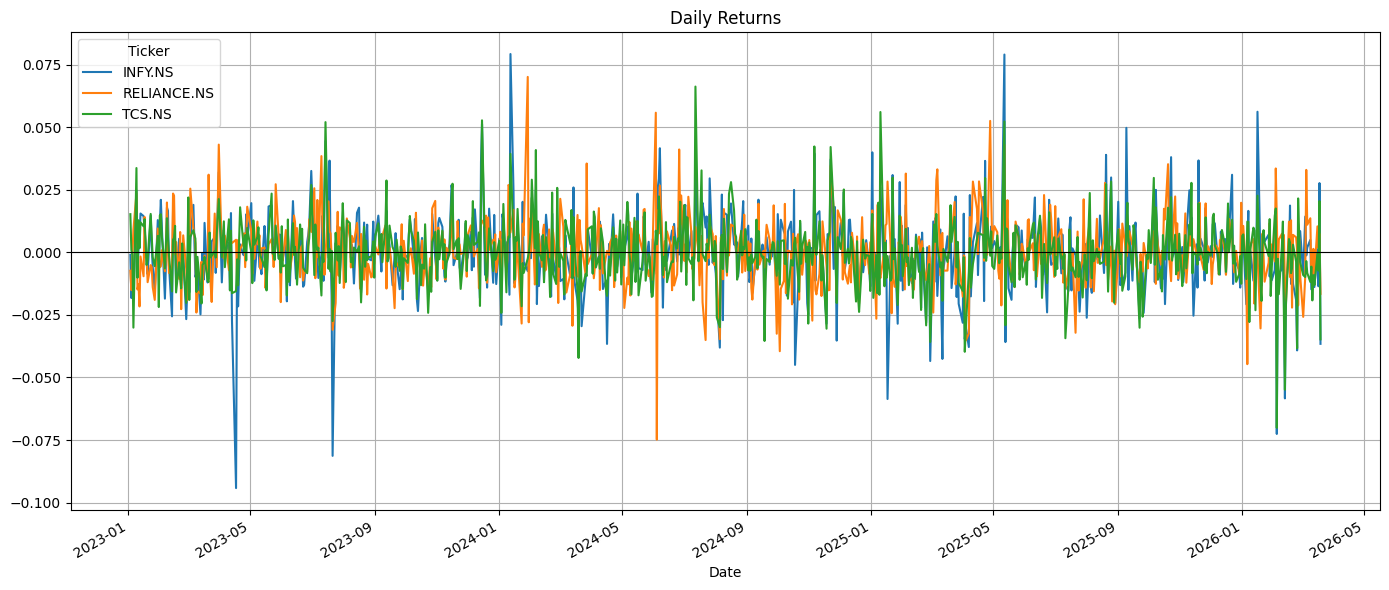

In [68]:
daily_returns = data.pct_change().dropna()

daily_returns.plot(figsize=(14,6), title='Daily Returns')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True)
plt.tight_layout()
plt.show()

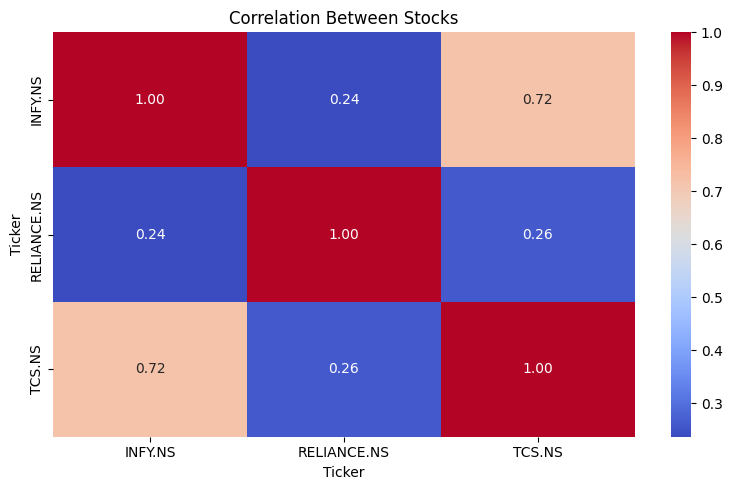

In [69]:
plt.figure(figsize=(8,5))
sns.heatmap(daily_returns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Stocks')
plt.tight_layout()
plt.show()